# Импорт библиотек

In [1]:
%pip install -q -U albumentations opencv-python-headless segmentation-models-pytorch ultralytics pandas scikit-learn tqdm pyyaml

Note: you may need to restart the kernel to use updated packages.


In [1]:
import os
import re
import random
import requests
import shutil
import zipfile
from pathlib import Path
from urllib.parse import urlencode

import cv2
import yaml
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from PIL import Image
from tqdm.auto import tqdm

import torch
import torch.nn as nn
import torch.nn.functional as F
from torch.utils.data import Dataset, DataLoader

from sklearn.model_selection import GroupShuffleSplit

import albumentations as A
from albumentations.pytorch import ToTensorV2

import segmentation_models_pytorch as smp
from ultralytics import YOLO

c:\Users\linus\PycharmProjects\machine_learning\.venv\Lib\site-packages\tqdm\auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


In [ ]:
print("torch: ", torch.__version__)
print("cuda available:", torch.cuda.is_available())

torch: 2.11.0+cu126
cuda available: True


## Конфиг

In [ ]:
PUBLIC_YANDEX_URL = "https://disk.yandex.ru/d/v3KwZ5UJ8Uoshw"

WORKDIR = Path("./carvana_work")
RAW_DIR = WORKDIR / "raw"
EXTRACT_DIR = WORKDIR / "extracted"
MODEL_DIR = WORKDIR / "models"
YOLO_DIR = WORKDIR / "yolo_dataset"
REPORT_DIR = WORKDIR / "reports"

for p in [WORKDIR, RAW_DIR, EXTRACT_DIR, MODEL_DIR, YOLO_DIR, REPORT_DIR]:
    p.mkdir(parents=True, exist_ok=True)

SEED = 42
VAL_SIZE = 0.2
DEBUG_MAX_SAMPLES = None
NUM_WORKERS = min(4, os.cpu_count() or 2) if torch.cuda.is_available() else 0

IMG_SIZE = (256, 256)
BATCH_SIZE = 16 if torch.cuda.is_available() else 4
EPOCHS = 10
LR = 1e-3
ENCODER_NAME = "mobilenet_v2"
THRESHOLD = 0.5

RUN_CUSTOM_UNET = False
CUSTOM_UNET_EPOCHS = 6
CUSTOM_BASE_CHANNELS = 32

device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
use_amp = torch.cuda.is_available()
cv2.setNumThreads(0)

if torch.cuda.is_available():
    torch.backends.cudnn.benchmark = True
    torch.backends.cuda.matmul.allow_tf32 = True
    torch.backends.cudnn.allow_tf32 = True
    torch.set_float32_matmul_precision("high")
print("device:", device)

device: cuda


In [4]:
def seed_everything(seed: int = 42) -> None:
    random.seed(seed)
    np.random.seed(seed)
    torch.manual_seed(seed)
    torch.cuda.manual_seed_all(seed)
    os.environ["PYTHONHASHSEED"] = str(seed)

seed_everything(SEED)

# Загрузка датасета с Yandex Disk

Используется официальный паттерн из документации Yandex Cloud для публичных ресурсов Yandex Disk:
сначала запрашивается `public/resources/download?public_key=...`, затем скачивается URL из поля `href`.

In [5]:
def resolve_yandex_download_url(public_key: str) -> str:
    base_url = "https://cloud-api.yandex.net/v1/disk/public/resources/download?"
    final_url = base_url + urlencode({"public_key": public_key})
    response = requests.get(final_url, timeout=60)
    response.raise_for_status()
    payload = response.json()
    if "href" not in payload:
        raise RuntimeError(f"Yandex Disk did not return direct download link: {payload}")
    return payload["href"]

In [6]:
def download_file(url: str, dst_path: Path, chunk_size: int = 2**20) -> Path:
    dst_path.parent.mkdir(parents=True, exist_ok=True)
    with requests.get(url, stream=True, timeout=120) as r:
        r.raise_for_status()
        total = int(r.headers.get("content-length", 0))
        with open(dst_path, "wb") as f, tqdm(total=total, unit="B", unit_scale=True, desc=dst_path.name) as pbar:
            for chunk in r.iter_content(chunk_size=chunk_size):
                if chunk:
                    f.write(chunk)
                    pbar.update(len(chunk))
    return dst_path

In [7]:
def extract_zip(archive_path: Path, dst_dir: Path) -> None:
    dst_dir.mkdir(parents=True, exist_ok=True)
    with zipfile.ZipFile(archive_path, "r") as zf:
        zf.extractall(dst_dir)

In [8]:
outer_archive = RAW_DIR / "carvana-image-masking-challenge.zip"

if not outer_archive.exists():
    direct_url = resolve_yandex_download_url(PUBLIC_YANDEX_URL)
    download_file(direct_url, outer_archive)
else:
    print("Архив уже скачан:", outer_archive)

if not any(EXTRACT_DIR.iterdir()):
    extract_zip(outer_archive, EXTRACT_DIR)
    print("Внешний архив распакован в", EXTRACT_DIR)
else:
    print("Внешний архив уже распакован:", EXTRACT_DIR)

Архив уже скачан: carvana_work\raw\carvana-image-masking-challenge.zip
Внешний архив уже распакован: carvana_work\extracted


In [9]:
IMG_EXTS = {".jpg", ".jpeg", ".png", ".bmp", ".webp"}
MASK_EXTS = {".png", ".jpg", ".jpeg", ".bmp", ".tif", ".tiff", ".gif"}

In [18]:
def list_files_by_ext(root: Path, exts: set[str]) -> list[Path]:
    return [p for p in root.rglob("*") if p.is_file() and p.suffix.lower() in exts]

In [10]:
def has_enough_pairs(root: Path) -> bool:
    image_files = [p for p in list_files_by_ext(root, IMG_EXTS) if "_mask" not in p.stem.lower()]
    mask_files = [p for p in list_files_by_ext(root, MASK_EXTS) if ("mask" in p.stem.lower() or "mask" in str(p.parent).lower())]
    return len(image_files) > 100 and len(mask_files) > 100

In [11]:
def extract_relevant_inner_archives(root: Path) -> None:
    if has_enough_pairs(root):
        print("Похоже, train-изображения и маски уже доступны, дополнительные zip извлекать не нужно.")
        return

    inner_archives = sorted(root.rglob("*.zip"))
    if not inner_archives:
        print("Вложенных архивов не найдено.")
        return

    def score(path: Path) -> int:
        name = path.name.lower()
        s = 0
        if "train" in name:
            s += 3
        if "mask" in name:
            s += 3
        if "test" in name:
            s -= 5
        if "sample" in name or "submission" in name:
            s -= 3
        return s

    selected = [p for p in inner_archives if score(p) > 0]
    selected = sorted(selected, key=score, reverse=True)

    print("Будут извлечены вложенные архивы:")
    for p in selected:
        print(" -", p)

    for archive_path in selected:
        dst = archive_path.with_suffix("")
        if dst.exists() and any(dst.iterdir()):
            print("Уже извлечён:", dst)
            continue
        print("Извлекаю:", archive_path.name)
        extract_zip(archive_path, dst)

In [14]:
extract_relevant_inner_archives(EXTRACT_DIR)

Похоже, train-изображения и маски уже доступны, дополнительные zip извлекать не нужно.


# Обнаружение структуры датасета и таблица пар `image-mask`

In [12]:
def canonical_image_key(path: Path) -> str:
    return path.stem

In [13]:
def canonical_mask_key(path: Path) -> str:
    return re.sub(r"_mask$", "", path.stem)

In [14]:
def rank_image_path(path: Path) -> tuple:
    s = str(path).lower()
    return (
        int("train_hq" in s),
        int("/train/" in s or "\\train\\" in s or "train" in path.parent.name.lower()),
        path.stat().st_size if path.exists() else 0,
    )

In [15]:
def rank_mask_path(path: Path) -> tuple:
    s = str(path).lower()
    return (
        int("train_masks" in s),
        int("mask" in s),
        path.stat().st_size if path.exists() else 0,
    )

In [16]:
def discover_image_mask_pairs(root: Path) -> pd.DataFrame:
    image_candidates = {}
    for p in list_files_by_ext(root, IMG_EXTS):
        if p.name.startswith("."):
            continue
        if "_mask" in p.stem.lower():
            continue
        image_candidates.setdefault(canonical_image_key(p), []).append(p)

    mask_candidates = {}
    for p in list_files_by_ext(root, MASK_EXTS):
        # исключаем скрытые файлы
        if p.name.startswith("."):
            continue
        if "mask" not in p.stem.lower() and "mask" not in str(p.parent).lower():
            continue
        mask_candidates.setdefault(canonical_mask_key(p), []).append(p)

    image_map = {k: sorted(v, key=rank_image_path, reverse=True)[0] for k, v in image_candidates.items()}
    mask_map = {k: sorted(v, key=rank_mask_path, reverse=True)[0] for k, v in mask_candidates.items()}

    common_ids = sorted(set(image_map) & set(mask_map))
    if not common_ids:
        raise RuntimeError(
            "Не удалось найти пары image-mask. Проверьте структуру архива после распаковки."
        )

    rows = []
    for sample_id in common_ids:
        image_path = image_map[sample_id]
        mask_path = mask_map[sample_id]
        parts = sample_id.split("_")
        car_id = parts[0]
        angle_id = parts[1] if len(parts) > 1 else None
        rows.append(
            {
                "id": sample_id,
                "car_id": car_id,
                "angle_id": angle_id,
                "image_path": str(image_path),
                "mask_path": str(mask_path),
            }
        )

    df = pd.DataFrame(rows).sort_values("id").reset_index(drop=True)
    return df

In [19]:
df = discover_image_mask_pairs(EXTRACT_DIR)
print("Всего пар image-mask:", len(df))
df.head()

Всего пар image-mask: 105152


,id,car_id,angle_id,image_path,mask_path
0,0004d4463b50_01,0004d4463b50,01,carvana_work\extracted\carvana-image-masking-c...,carvana_work\extracted\carvana-image-masking-c...
1,0004d4463b50_02,0004d4463b50,02,carvana_work\extracted\carvana-image-masking-c...,carvana_work\extracted\carvana-image-masking-c...
2,0004d4463b50_03,0004d4463b50,03,carvana_work\extracted\carvana-image-masking-c...,carvana_work\extracted\carvana-image-masking-c...
3,0004d4463b50_04,0004d4463b50,04,carvana_work\extracted\carvana-image-masking-c...,carvana_work\extracted\carvana-image-masking-c...
4,0004d4463b50_05,0004d4463b50,05,carvana_work\extracted\carvana-image-masking-c...,carvana_work\extracted\carvana-image-masking-c...


In [20]:
if DEBUG_MAX_SAMPLES is not None:
    unique_cars = df["car_id"].drop_duplicates().sample(frac=1.0, random_state=SEED).tolist()
    selected_cars = []
    selected_count = 0
    for car_id in unique_cars:
        car_rows = df[df["car_id"] == car_id]
        if selected_count + len(car_rows) > DEBUG_MAX_SAMPLES and selected_cars:
            break
        selected_cars.append(car_id)
        selected_count += len(car_rows)
    df = df[df["car_id"].isin(selected_cars)].reset_index(drop=True)
    print(f"DEBUG режим: оставлено {len(df)} изображений из {df['car_id'].nunique()} автомобилей")

In [21]:
metadata_files = list(EXTRACT_DIR.rglob("metadata.csv"))
metadata_df = None

In [22]:
if metadata_files:
    metadata_df = pd.read_csv(metadata_files[0])
    print("Найден metadata.csv:", metadata_files[0])
    display(metadata_df.head())
    print("Колонки metadata:", metadata_df.columns.tolist())
else:
    print("metadata.csv не найден — это не мешает обучению.")

Найден metadata.csv: carvana_work\extracted\carvana-image-masking-challenge\metadata.csv


,id,year,make,model,trim1,trim2
0,0004d4463b50,2014.0,Acura,TL,TL,w/SE
1,00087a6bd4dc,2014.0,Acura,RLX,RLX,w/Tech
2,000aa097d423,2012.0,Mazda,MAZDA6,MAZDA6,i Sport
3,000f19f6e7d4,2016.0,Chevrolet,Camaro,Camaro,SS
4,00144e887ae9,2015.0,Acura,TLX,TLX,SH-AWD V6 w/Advance Pkg


Колонки metadata: ['id', 'year', 'make', 'model', 'trim1', 'trim2']


# EDA: размеры изображений, доля foreground, примеры

По данным открытых описаний датасета, в исходном наборе один автомобиль дан в 16 фиксированных ракурсах,
а сами изображения имеют высокое разрешение.

In [23]:
def load_rgb(path: str | Path) -> np.ndarray:
    image = cv2.imread(str(path), cv2.IMREAD_COLOR)
    if image is None:
        raise FileNotFoundError(path)
    return cv2.cvtColor(image, cv2.COLOR_BGR2RGB)

In [24]:
def load_mask(path: str | Path) -> np.ndarray:
    mask = np.array(Image.open(path).convert("L"))
    return mask

In [25]:
def get_image_size(path: str | Path) -> tuple[int, int]:
    with Image.open(path) as img:
        w, h = img.size
    return h, w

In [26]:
size_rows = []
for path in tqdm(df["image_path"], desc="Размеры изображений"):
    try:
        h, w = get_image_size(path)
        size_rows.append((h, w))
    except TypeError:
        print(path)

Размеры изображений: 100%|██████████| 105152/105152 [01:21<00:00, 1283.34it/s]


In [27]:
sizes_df = pd.DataFrame(size_rows, columns=["height", "width"])
display(sizes_df.describe().T)
print("Уникальные размеры:", sizes_df.drop_duplicates().values.tolist()[:10])

,count,mean,std,min,25%,50%,75%,max
height,105152.0,1280.0,0.0,1280.0,1280.0,1280.0,1280.0,1280.0
width,105152.0,1918.0,0.0,1918.0,1918.0,1918.0,1918.0,1918.0


Уникальные размеры: [[1280, 1918]]


Foreground coverage: 100%|██████████| 256/256 [00:04<00:00, 52.85it/s]


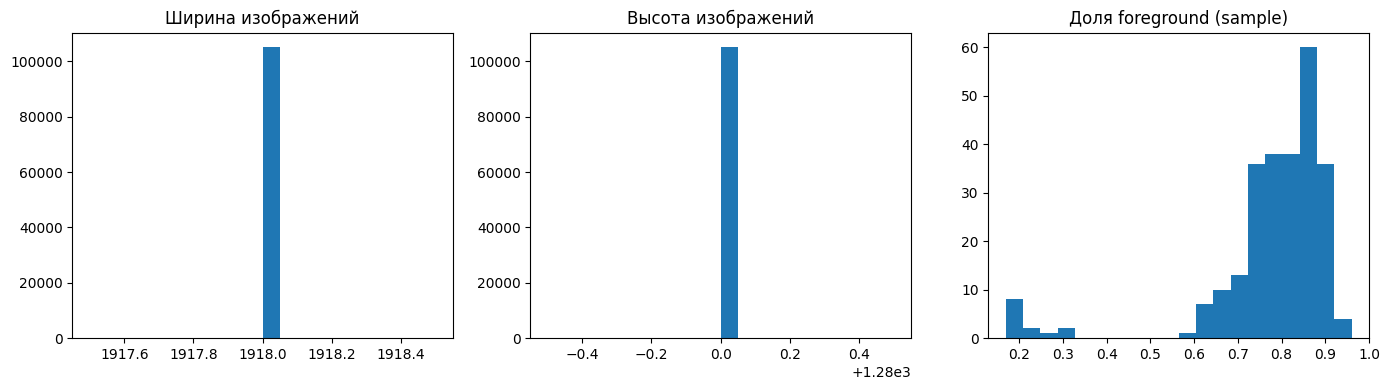

Средняя доля foreground (sample): 0.7791608572006226
Медианная доля foreground (sample): 0.8155843019485474


In [28]:
sample_for_mask_stats = df.sample(min(len(df), 256), random_state=SEED).reset_index(drop=True)

mask_coverages = []
for path in tqdm(sample_for_mask_stats["mask_path"], desc="Foreground coverage"):
    mask = load_mask(path)
    mask_bin = (mask > 127).astype(np.float32)
    mask_coverages.append(mask_bin.mean())

mask_coverages = np.array(mask_coverages)

fig = plt.figure(figsize=(14, 4))
plt.subplot(1, 3, 1)
plt.hist(sizes_df["width"], bins=20)
plt.title("Ширина изображений")

plt.subplot(1, 3, 2)
plt.hist(sizes_df["height"], bins=20)
plt.title("Высота изображений")

plt.subplot(1, 3, 3)
plt.hist(mask_coverages, bins=20)
plt.title("Доля foreground (sample)")
plt.tight_layout()
plt.show()

print("Средняя доля foreground (sample):", float(mask_coverages.mean()))
print("Медианная доля foreground (sample):", float(np.median(mask_coverages)))

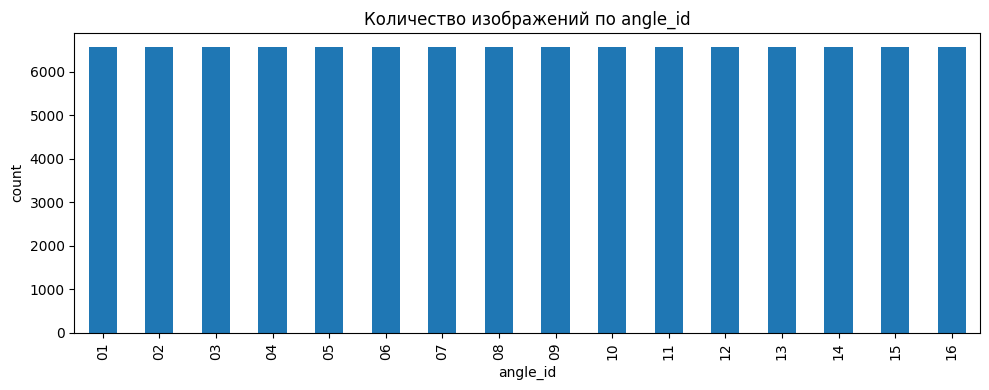

In [29]:
if "angle_id" in df.columns and df["angle_id"].notna().any():
    angle_counts = df["angle_id"].value_counts().sort_index()
    fig = plt.figure(figsize=(10, 4))
    angle_counts.plot(kind="bar")
    plt.title("Количество изображений по angle_id")
    plt.xlabel("angle_id")
    plt.ylabel("count")
    plt.tight_layout()
    plt.show()

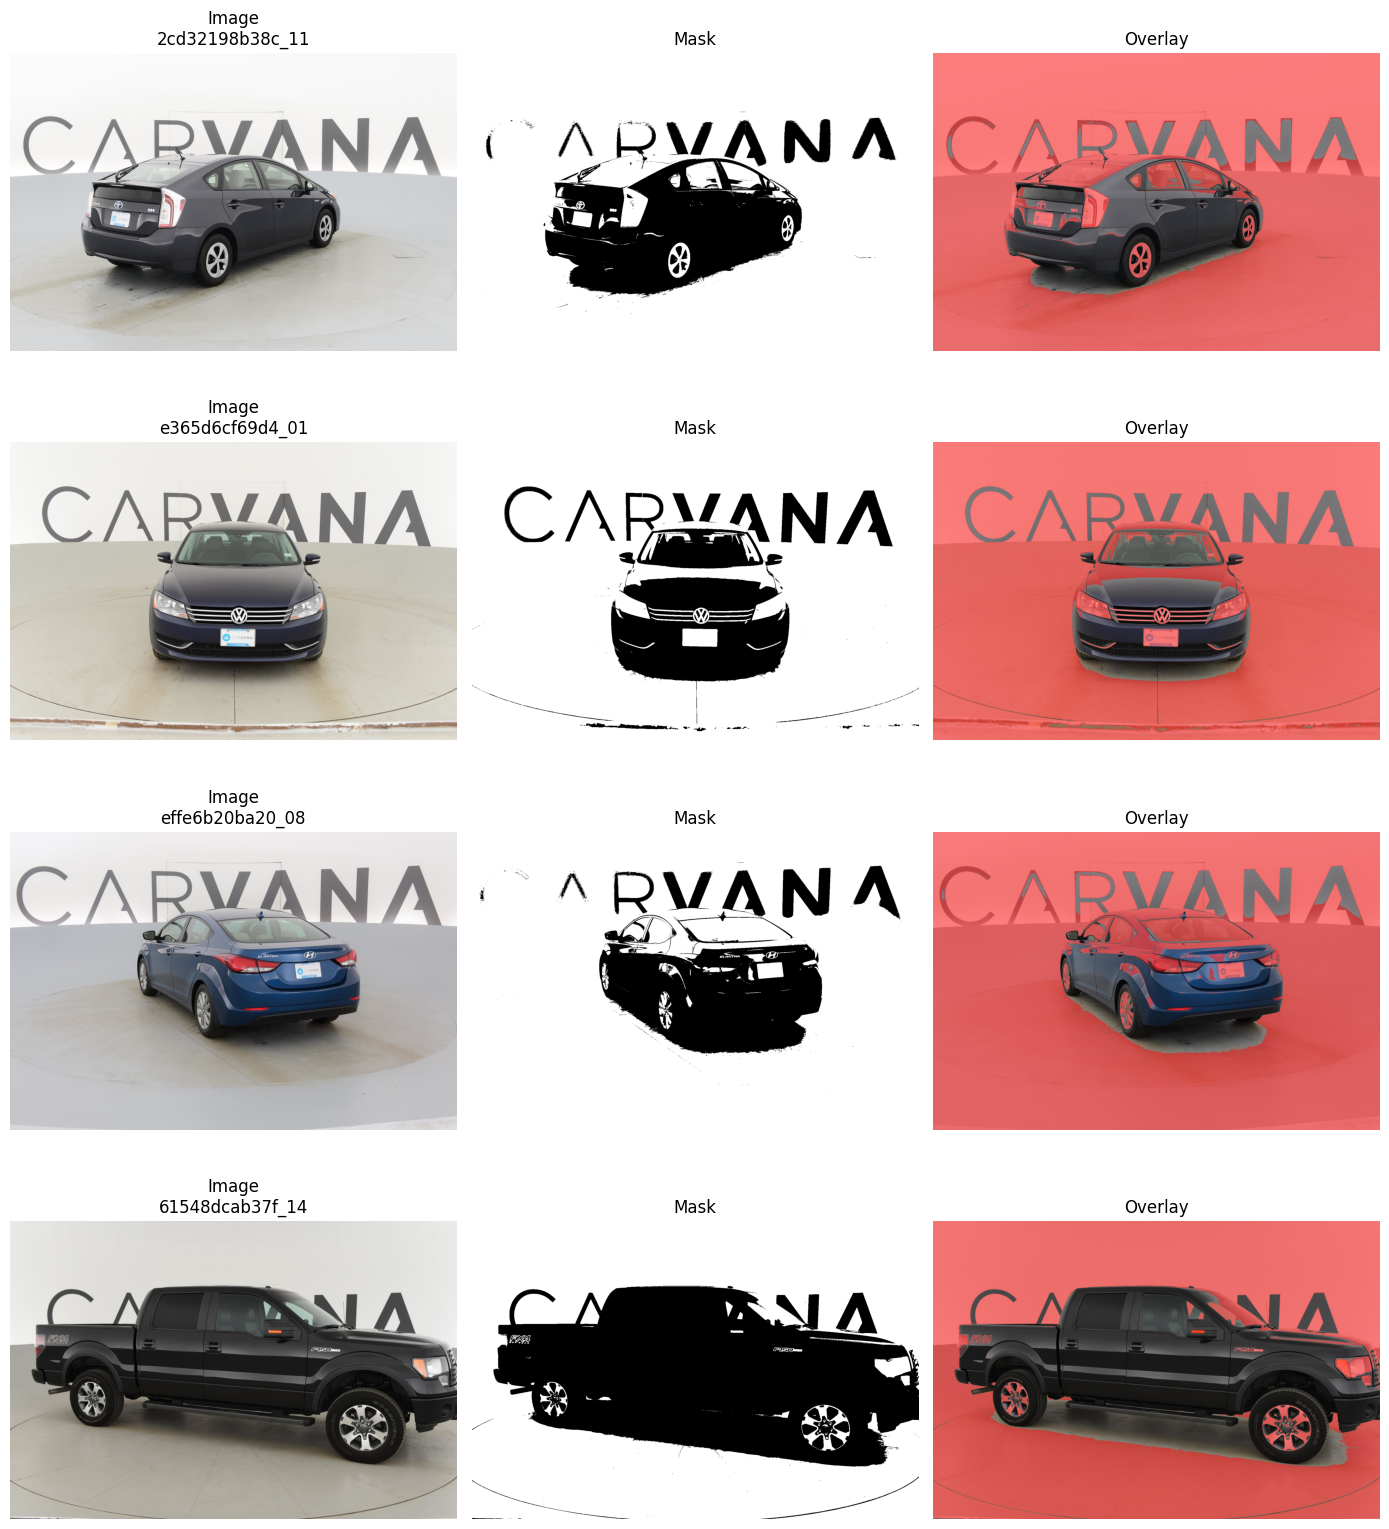

In [30]:
def show_random_samples(df: pd.DataFrame, n: int = 4, seed: int = 42) -> None:
    sample_df = df.sample(min(n, len(df)), random_state=seed).reset_index(drop=True)
    fig, axes = plt.subplots(len(sample_df), 3, figsize=(14, 4 * len(sample_df)))

    if len(sample_df) == 1:
        axes = np.expand_dims(axes, axis=0)

    for i, row in sample_df.iterrows():
        image = load_rgb(row["image_path"])
        mask = load_mask(row["mask_path"])
        mask_bin = (mask > 127).astype(np.uint8)

        overlay = image.copy()
        overlay[mask_bin == 1] = (0.5 * overlay[mask_bin == 1] + 0.5 * np.array([255, 0, 0])).astype(np.uint8)

        axes[i, 0].imshow(image)
        axes[i, 0].set_title(f"Image\n{row['id']}")
        axes[i, 1].imshow(mask_bin, cmap="gray")
        axes[i, 1].set_title("Mask")
        axes[i, 2].imshow(overlay)
        axes[i, 2].set_title("Overlay")

        for j in range(3):
            axes[i, j].axis("off")

    plt.tight_layout()
    plt.show()

show_random_samples(df, n=4, seed=SEED)

# Train/val split по `car_id`

Это важная деталь. Поскольку один и тот же автомобиль присутствует в 16 ракурсах, случайный split по изображениям
может привести к утечке: тот же автомобиль окажется и в train, и в val. Поэтому split делаем по `car_id`.

In [31]:
splitter = GroupShuffleSplit(n_splits=1, test_size=VAL_SIZE, random_state=SEED)
train_idx, val_idx = next(splitter.split(df, groups=df["car_id"]))

In [32]:
train_df = df.iloc[train_idx].reset_index(drop=True)
val_df = df.iloc[val_idx].reset_index(drop=True)

In [33]:
print("train:", len(train_df), "images,", train_df["car_id"].nunique(), "cars")
print("val:", len(val_df), "images,", val_df["car_id"].nunique(), "cars")
print("Пересечение car_id:", len(set(train_df["car_id"]) & set(val_df["car_id"])))

train: 84112 images, 5257 cars
val: 21040 images, 1315 cars
Пересечение car_id: 0


# Предобработка и аугментация

In [34]:
IMAGENET_MEAN = (0.485, 0.456, 0.406)
IMAGENET_STD = (0.229, 0.224, 0.225)

In [35]:
train_transform = A.Compose(
    [
        A.Resize(IMG_SIZE[0], IMG_SIZE[1]),
        A.HorizontalFlip(p=0.5),
        A.Normalize(mean=IMAGENET_MEAN, std=IMAGENET_STD),
        ToTensorV2(),
    ]
)

In [36]:
valid_transform = A.Compose(
    [
        A.Resize(IMG_SIZE[0], IMG_SIZE[1]),
        A.Normalize(mean=IMAGENET_MEAN, std=IMAGENET_STD),
        ToTensorV2(),
    ]
)

In [37]:
class CarvanaSegDataset(Dataset):
    def __init__(self, frame: pd.DataFrame, transforms=None):
        self.image_paths = frame["image_path"].astype(str).tolist()
        self.mask_paths = frame["mask_path"].astype(str).tolist()
        self.transforms = transforms

    def __len__(self):
        return len(self.image_paths)

    def __getitem__(self, idx):
        image = cv2.imread(self.image_paths[idx], cv2.IMREAD_COLOR)
        image = cv2.cvtColor(image, cv2.COLOR_BGR2RGB)

        mask = cv2.imread(self.mask_paths[idx], cv2.IMREAD_GRAYSCALE)
        mask = (mask > 127).astype(np.float32)   # H, W

        if self.transforms is not None:
            transformed = self.transforms(image=image, mask=mask)
            image = transformed["image"]         # C, H, W
            mask = transformed["mask"]           # обычно H, W

        if mask.ndim == 2:
            mask = mask.unsqueeze(0)             # 1, H, W
        elif mask.ndim == 3 and mask.shape[-1] == 1:
            mask = mask.permute(2, 0, 1)         # H, W, 1 -> 1, H, W

        return image, mask.float()

In [38]:
train_ds = CarvanaSegDataset(train_df, transforms=train_transform)
val_ds = CarvanaSegDataset(val_df, transforms=valid_transform)

In [39]:
train_loader = DataLoader(
    train_ds,
    batch_size=BATCH_SIZE,
    shuffle=True,
    num_workers=NUM_WORKERS,
    pin_memory=torch.cuda.is_available(),
    persistent_workers=NUM_WORKERS > 0,
    prefetch_factor=4 if NUM_WORKERS > 0 else None,
    drop_last=True,
)

In [40]:
val_loader = DataLoader(
    val_ds,
    batch_size=BATCH_SIZE,
    shuffle=False,
    num_workers=NUM_WORKERS,
    pin_memory=torch.cuda.is_available(),
    persistent_workers=NUM_WORKERS > 0,
    prefetch_factor=4 if NUM_WORKERS > 0 else None,
)

In [41]:
xb, yb = next(iter(train_loader))
print("Batch images:", xb.shape, xb.dtype)
print("Batch masks:", yb.shape, yb.dtype, yb.min().item(), yb.max().item())

Batch images: torch.Size([16, 3, 256, 256]) torch.float32
Batch masks: torch.Size([16, 1, 256, 256]) torch.float32 0.0 1.0


In [42]:
def visualize_augmented_batch(dataset: Dataset, n: int = 3):
    fig, axes = plt.subplots(n, 2, figsize=(8, 4 * n))
    if n == 1:
        axes = np.expand_dims(axes, axis=0)

    for i in range(n):
        image_t, mask_t = dataset[i]
        image = image_t.permute(1, 2, 0).cpu().numpy()
        image = (image * np.array(IMAGENET_STD) + np.array(IMAGENET_MEAN))
        image = np.clip(image, 0, 1)
        mask = mask_t.squeeze(0).cpu().numpy()

        axes[i, 0].imshow(image)
        axes[i, 0].set_title("Augmented image")
        axes[i, 1].imshow(mask, cmap="gray")
        axes[i, 1].set_title("Augmented mask")
        axes[i, 0].axis("off")
        axes[i, 1].axis("off")

    plt.tight_layout()
    plt.show()

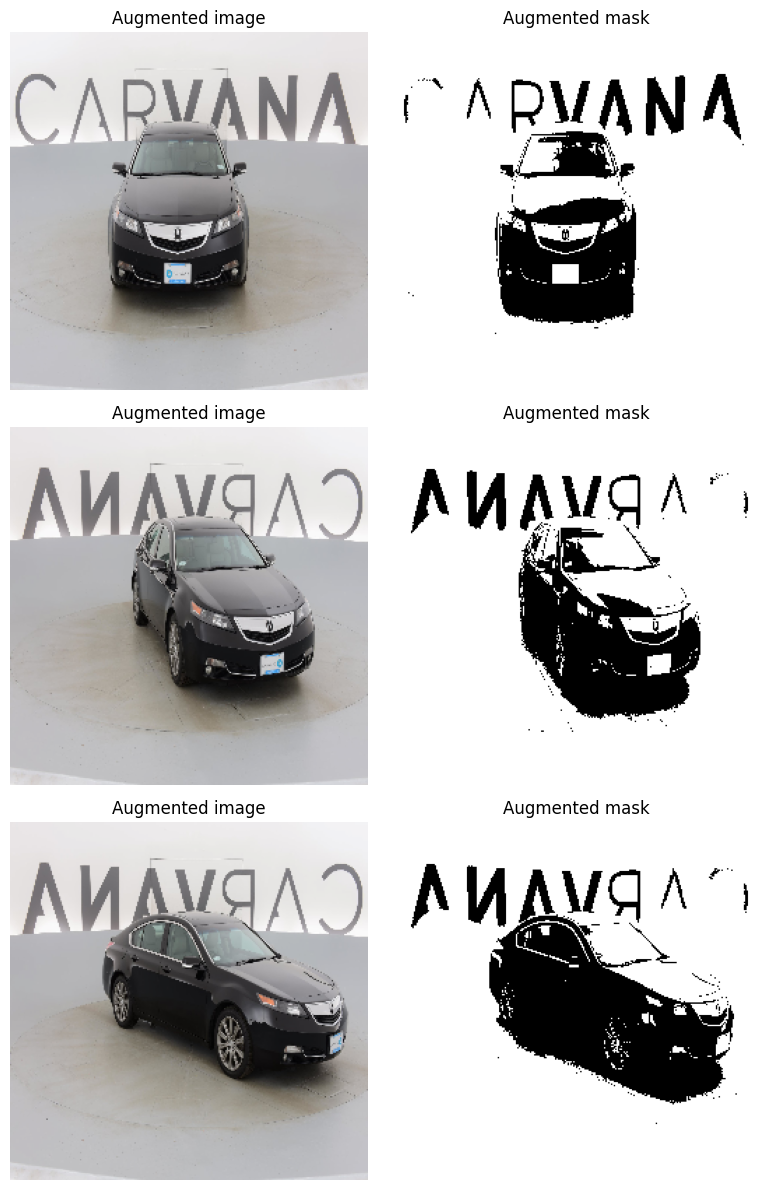

In [43]:

visualize_augmented_batch(train_ds, n=3)

# Функции потерь, метрики и training loop

In [44]:
class DiceLossBinary(nn.Module):
    def __init__(self, smooth: float = 1.0):
        super().__init__()
        self.smooth = smooth

    def forward(self, logits: torch.Tensor, targets: torch.Tensor) -> torch.Tensor:
        probs = torch.sigmoid(logits)
        dims = (1, 2, 3)
        intersection = (probs * targets).sum(dim=dims)
        denominator = probs.sum(dim=dims) + targets.sum(dim=dims)
        dice = (2.0 * intersection + self.smooth) / (denominator + self.smooth)
        return 1.0 - dice.mean()

In [45]:
bce_loss = nn.BCEWithLogitsLoss()
dice_loss = DiceLossBinary()

In [46]:
def batch_iou_dice_from_logits(
    logits: torch.Tensor,
    targets: torch.Tensor,
    threshold: float = 0.5,
    eps: float = 1e-7,
) -> tuple[float, float]:
    probs = torch.sigmoid(logits)
    preds = (probs > threshold).float()

    dims = (1, 2, 3)
    intersection = (preds * targets).sum(dim=dims)
    union = preds.sum(dim=dims) + targets.sum(dim=dims) - intersection
    dice_den = preds.sum(dim=dims) + targets.sum(dim=dims)

    iou = ((intersection + eps) / (union + eps)).mean().item()
    dice = ((2 * intersection + eps) / (dice_den + eps)).mean().item()
    return iou, dice

In [47]:
def make_smp_unet() -> nn.Module:
    model = smp.Unet(
        encoder_name=ENCODER_NAME,
        encoder_weights="imagenet",
        in_channels=3,
        classes=1,
        activation=None,
    )
    return model

In [48]:
def run_epoch(
    model: nn.Module,
    loader: DataLoader,
    loss_fn: nn.Module,
    optimizer: torch.optim.Optimizer | None = None,
    threshold: float = THRESHOLD,
    scaler: torch.amp.GradScaler | None = None,
):
    is_train = optimizer is not None
    model.train(is_train)

    scaler = scaler if is_train else None

    losses = []
    ious = []
    dices = []

    pbar = tqdm(loader, leave=False)

    for images, masks in pbar:
        images = images.to(device, non_blocking=True).to(memory_format=torch.channels_last)
        masks = masks.to(device, non_blocking=True)

        if is_train:
            optimizer.zero_grad(set_to_none=True)

        with torch.set_grad_enabled(is_train):
            with torch.amp.autocast("cuda", enabled=use_amp):
                logits = model(images)
                loss = loss_fn(logits, masks)

        if is_train:
            scaler.scale(loss).backward()
            scaler.step(optimizer)
            scaler.update()
            losses.append(loss.item())
            pbar.set_description(f"train loss={np.mean(losses):.4f}")
        else:
            iou, dice = batch_iou_dice_from_logits(logits, masks, threshold=threshold)
            losses.append(loss.item())
            ious.append(iou)
            dices.append(dice)
            pbar.set_description(
                f"valid loss={np.mean(losses):.4f} dice={np.mean(dices):.4f}"
            )

    return {
        "loss": float(np.mean(losses)),
        "iou": float(np.mean(ious)) if ious else float("nan"),
        "dice": float(np.mean(dices)) if dices else float("nan"),
    }

In [49]:
def train_model(
    model: nn.Module,
    train_loader: DataLoader,
    val_loader: DataLoader,
    loss_fn: nn.Module,
    epochs: int,
    lr: float,
    experiment_name: str,
    validate_every: int = 2,
):
    optimizer = torch.optim.AdamW(model.parameters(), lr=lr, weight_decay=1e-4)
    scaler = torch.amp.GradScaler("cuda", enabled=use_amp)
    scheduler = torch.optim.lr_scheduler.ReduceLROnPlateau(
        optimizer, mode="max", factor=0.5, patience=2
    )

    history = []
    best_dice = -np.inf
    best_path = MODEL_DIR / f"{experiment_name}_best.pt"

    for epoch in range(1, epochs + 1):
        train_metrics = run_epoch(model, train_loader, loss_fn, optimizer=optimizer, scaler=scaler)

        if epoch % validate_every == 0 or epoch == epochs:
            val_metrics = run_epoch(model, val_loader, loss_fn, optimizer=None)
            scheduler.step(val_metrics["dice"])
        else:
            val_metrics = {"loss": np.nan, "iou": np.nan, "dice": np.nan}

        row = {
            "epoch": epoch,
            "lr": optimizer.param_groups[0]["lr"],
            "train_loss": train_metrics["loss"],
            "train_iou": train_metrics["iou"],
            "train_dice": train_metrics["dice"],
            "val_loss": val_metrics["loss"],
            "val_iou": val_metrics["iou"],
            "val_dice": val_metrics["dice"],
        }
        history.append(row)

        print(
            f"[{experiment_name}] epoch {epoch:02d}/{epochs} | "
            f"train loss={train_metrics['loss']:.4f} | "
            f"val dice={val_metrics['dice'] if not np.isnan(val_metrics['dice']) else 'skip'}"
        )

        if not np.isnan(val_metrics["dice"]) and val_metrics["dice"] > best_dice:
            best_dice = val_metrics["dice"]
            torch.save(model.state_dict(), best_path)

    history_df = pd.DataFrame(history)
    history_df.to_csv(REPORT_DIR / f"{experiment_name}_history.csv", index=False)
    return history_df, best_path

# Библиотечная U-Net + BCE

In [ ]:
bce_model = make_smp_unet().to(device)
bce_model = bce_model.to(memory_format=torch.channels_last)
bce_history, bce_best_path = train_model(
    model=bce_model,
    train_loader=train_loader,
    val_loader=val_loader,
    loss_fn=bce_loss,
    epochs=EPOCHS,
    lr=LR,
    experiment_name="smp_unet_bce"
)

[smp_unet_bce] epoch 01/8 | train loss=0.1933 | val dice=skip


[smp_unet_bce] epoch 02/8 | train loss=0.1749 | val dice=0.9442777252554213


[smp_unet_bce] epoch 03/8 | train loss=0.1656 | val dice=skip


[smp_unet_bce] epoch 04/8 | train loss=0.1585 | val dice=0.9459982096497324


[smp_unet_bce] epoch 05/8 | train loss=0.1502 | val dice=skip


[smp_unet_bce] epoch 06/8 | train loss=0.1408 | val dice=0.9464876677940101


[smp_unet_bce] epoch 07/8 | train loss=0.1307 | val dice=skip


[smp_unet_bce] epoch 08/8 | train loss=0.1209 | val dice=0.9430304874513765


In [51]:
display(bce_history.tail())
print("best checkpoint:", bce_best_path)

,epoch,lr,train_loss,train_iou,train_dice,val_loss,val_iou,val_dice
3,4,0.001,0.158479,NaN,NaN,0.177817,0.932961,0.945998
4,5,0.001,0.150219,NaN,NaN,NaN,NaN,NaN
5,6,0.001,0.140843,NaN,NaN,0.181214,0.933368,0.946488
6,7,0.001,0.130668,NaN,NaN,NaN,NaN,NaN
7,8,0.001,0.120936,NaN,NaN,0.200237,0.928642,0.943030


best checkpoint: carvana_work\models\smp_unet_bce_best.pt


# Библиотечная U-Net + Dice Loss

In [52]:
dice_model = make_smp_unet().to(device)
dice_model = dice_model.to(memory_format=torch.channels_last)
dice_history, dice_best_path = train_model(
    model=dice_model,
    train_loader=train_loader,
    val_loader=val_loader,
    loss_fn=dice_loss,
    epochs=EPOCHS,
    lr=LR,
    experiment_name="smp_unet_dice",
)

[smp_unet_dice] epoch 01/8 | train loss=0.0505 | val dice=skip


[smp_unet_dice] epoch 02/8 | train loss=0.0461 | val dice=0.9474955459398009


[smp_unet_dice] epoch 03/8 | train loss=0.0455 | val dice=skip


[smp_unet_dice] epoch 04/8 | train loss=0.0451 | val dice=0.9485505860284708


[smp_unet_dice] epoch 05/8 | train loss=0.0449 | val dice=skip


[smp_unet_dice] epoch 06/8 | train loss=0.0445 | val dice=0.949122462622793


[smp_unet_dice] epoch 07/8 | train loss=0.0442 | val dice=skip


[smp_unet_dice] epoch 08/8 | train loss=0.0439 | val dice=0.9490511982896482


In [53]:
display(dice_history.tail())
print("best checkpoint:", dice_best_path)

,epoch,lr,train_loss,train_iou,train_dice,val_loss,val_iou,val_dice
3,4,0.001,0.045136,NaN,NaN,0.051472,0.936954,0.948551
4,5,0.001,0.044901,NaN,NaN,NaN,NaN,NaN
5,6,0.001,0.044546,NaN,NaN,0.050894,0.937645,0.949122
6,7,0.001,0.044161,NaN,NaN,NaN,NaN,NaN
7,8,0.001,0.043947,NaN,NaN,0.050962,0.937033,0.949051


best checkpoint: carvana_work\models\smp_unet_dice_best.pt


In [54]:
def plot_histories(histories: dict[str, pd.DataFrame], metric: str = "val_dice"):
    fig = plt.figure(figsize=(8, 4))
    for name, hist in histories.items():
        plt.plot(hist["epoch"], hist[metric], label=name)
    plt.xlabel("epoch")
    plt.ylabel(metric)
    plt.title(metric)
    plt.legend()
    plt.grid(True, alpha=0.3)
    plt.tight_layout()
    plt.show()

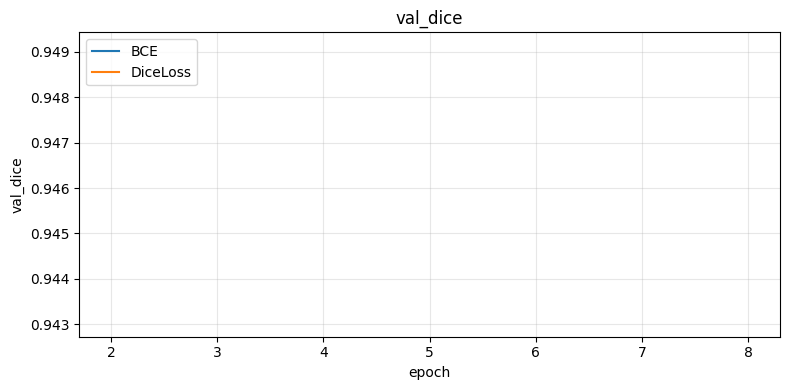

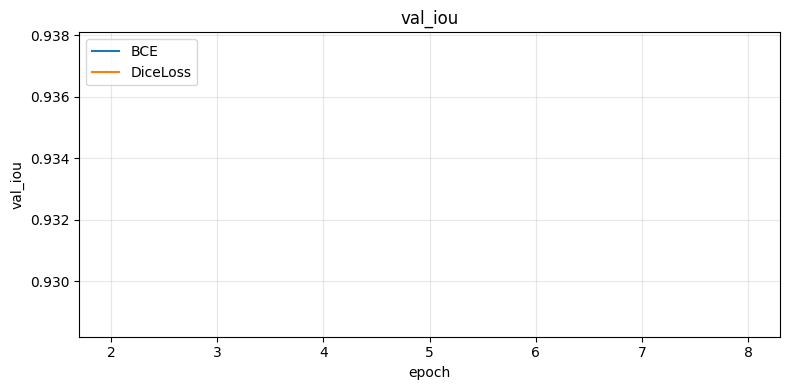

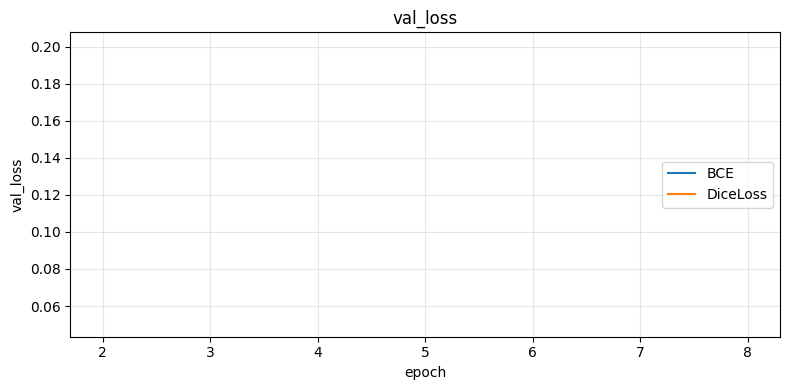

In [55]:
plot_histories({"BCE": bce_history, "DiceLoss": dice_history}, metric="val_dice")
plot_histories({"BCE": bce_history, "DiceLoss": dice_history}, metric="val_iou")
plot_histories({"BCE": bce_history, "DiceLoss": dice_history}, metric="val_loss")

# Оценка на исходном разрешении: IoU и Dice

Внутри батчей модель обучается на уменьшенных изображениях. Для финальной оценки на валидации:
1. читаем исходное изображение и mask;
2. уменьшаем изображение до `IMG_SIZE`;
3. получаем предсказание модели;
4. масштабируем probability map обратно до исходного разрешения;
5. считаем `IoU` и `Dice` на исходной маске.

In [56]:
@torch.inference_mode()
def predict_prob_map_unet(model: nn.Module, image_rgb: np.ndarray, image_size: tuple[int, int]) -> np.ndarray:
    transform = A.Compose(
        [
            A.Resize(image_size[0], image_size[1]),
            A.Normalize(mean=IMAGENET_MEAN, std=IMAGENET_STD),
            ToTensorV2(),
        ]
    )
    transformed = transform(image=image_rgb)
    x = transformed["image"].unsqueeze(0).to(device)
    logits = model(x)
    probs = torch.sigmoid(logits)[0, 0].detach().cpu().numpy()
    return probs

In [57]:
def binary_scores(pred_mask: np.ndarray, true_mask: np.ndarray, eps: float = 1e-7) -> tuple[float, float]:
    pred = (pred_mask > 0.5).astype(np.uint8)
    true = (true_mask > 0.5).astype(np.uint8)

    intersection = float((pred & true).sum())
    union = float((pred | true).sum())
    pred_sum = float(pred.sum())
    true_sum = float(true.sum())

    iou = (intersection + eps) / (union + eps)
    dice = (2 * intersection + eps) / (pred_sum + true_sum + eps)
    return iou, dice

In [58]:
@torch.inference_mode()
def evaluate_unet_on_dataframe(model: nn.Module, frame: pd.DataFrame) -> pd.DataFrame:
    model.eval()
    rows = []
    for row in tqdm(frame.itertuples(index=False), total=len(frame), desc="U-Net evaluation"):
        image = load_rgb(row.image_path)
        true_mask = (load_mask(row.mask_path) > 127).astype(np.uint8)

        prob_small = predict_prob_map_unet(model, image, IMG_SIZE)
        prob_full = cv2.resize(
            prob_small,
            (true_mask.shape[1], true_mask.shape[0]),
            interpolation=cv2.INTER_LINEAR,
        )

        iou, dice = binary_scores(prob_full, true_mask)
        rows.append({"id": row.id, "iou": iou, "dice": dice})

    return pd.DataFrame(rows)

In [59]:
best_bce_model = make_smp_unet().to(device)
best_bce_model = best_bce_model.to(memory_format=torch.channels_last)
best_bce_model.load_state_dict(torch.load(bce_best_path, map_location=device))

best_dice_model = make_smp_unet().to(device)
best_dice_model = best_dice_model.to(memory_format=torch.channels_last)
best_dice_model.load_state_dict(torch.load(dice_best_path, map_location=device))

bce_eval_df = evaluate_unet_on_dataframe(best_bce_model, val_df)
dice_eval_df = evaluate_unet_on_dataframe(best_dice_model, val_df)

summary_rows = [
    {"model": "smp_unet_bce", "val_iou_mean": bce_eval_df["iou"].mean(), "val_dice_mean": bce_eval_df["dice"].mean()},
    {"model": "smp_unet_dice", "val_iou_mean": dice_eval_df["iou"].mean(), "val_dice_mean": dice_eval_df["dice"].mean()},
]
summary_df = pd.DataFrame(summary_rows)
display(summary_df.sort_values("val_dice_mean", ascending=False))
summary_df.to_csv(REPORT_DIR / "unet_summary.csv", index=False)

U-Net evaluation: 100%|██████████| 21040/21040 [21:13<00:00, 16.52it/s]


,model,val_iou_mean,val_dice_mean
1,smp_unet_dice,0.923983,0.942203
0,smp_unet_bce,0.923530,0.941593


BCE model


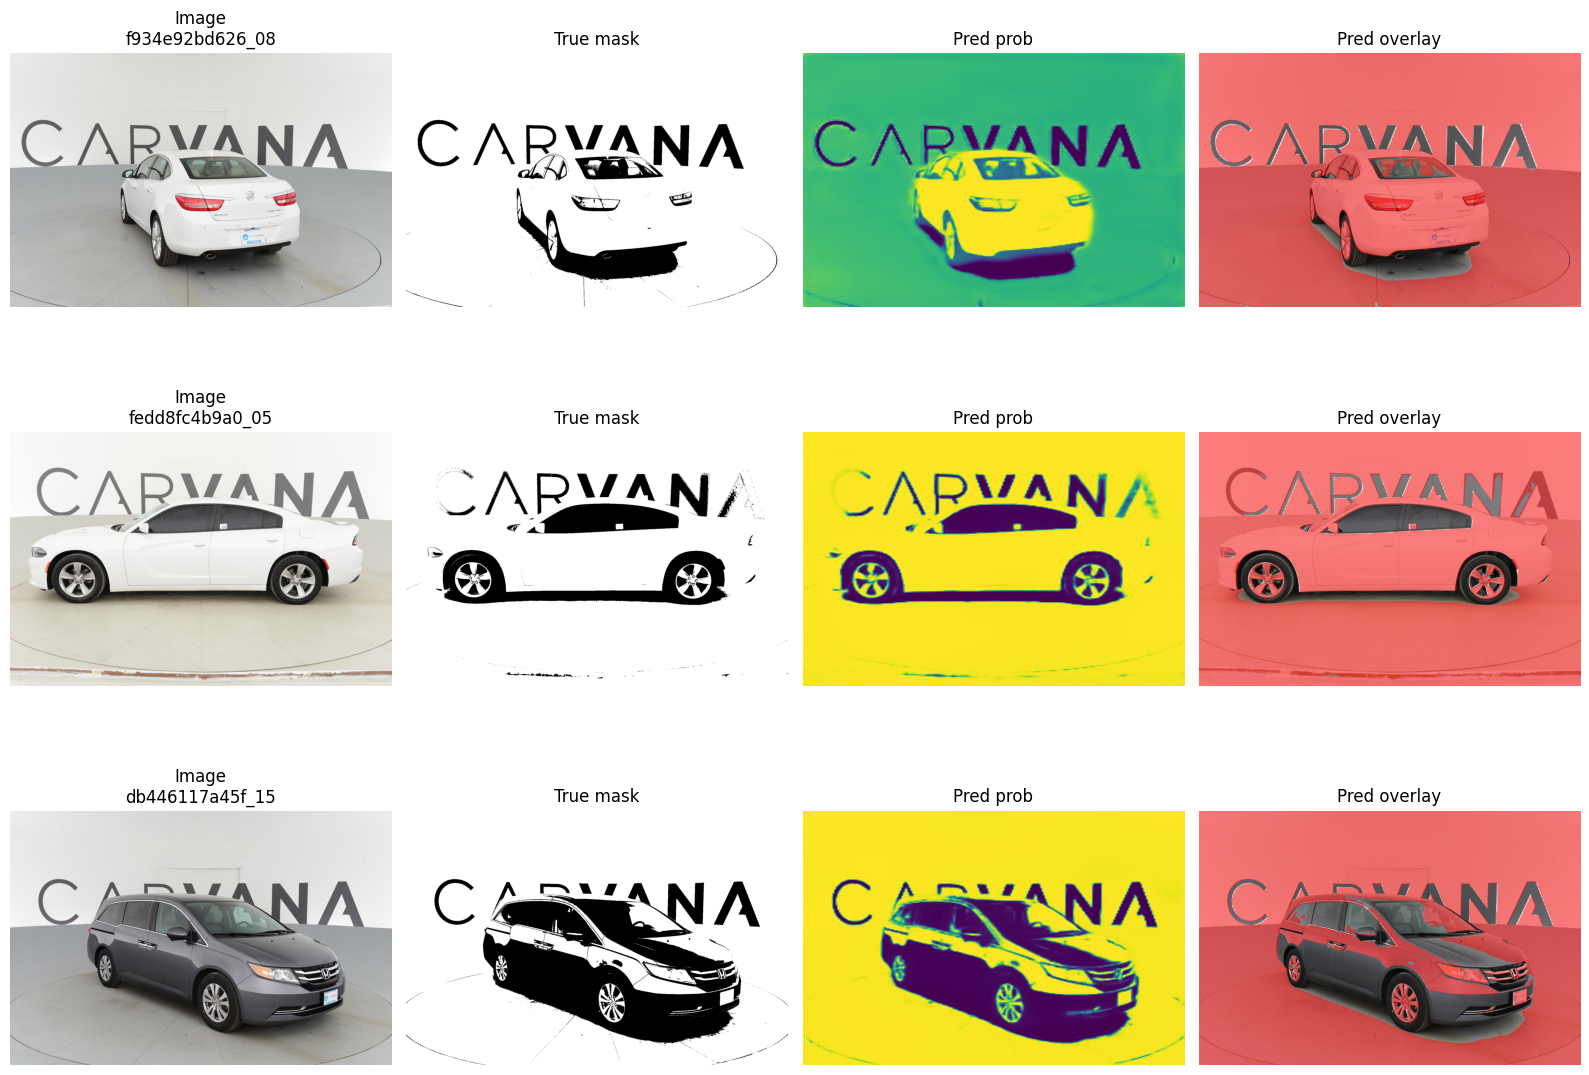

Dice model


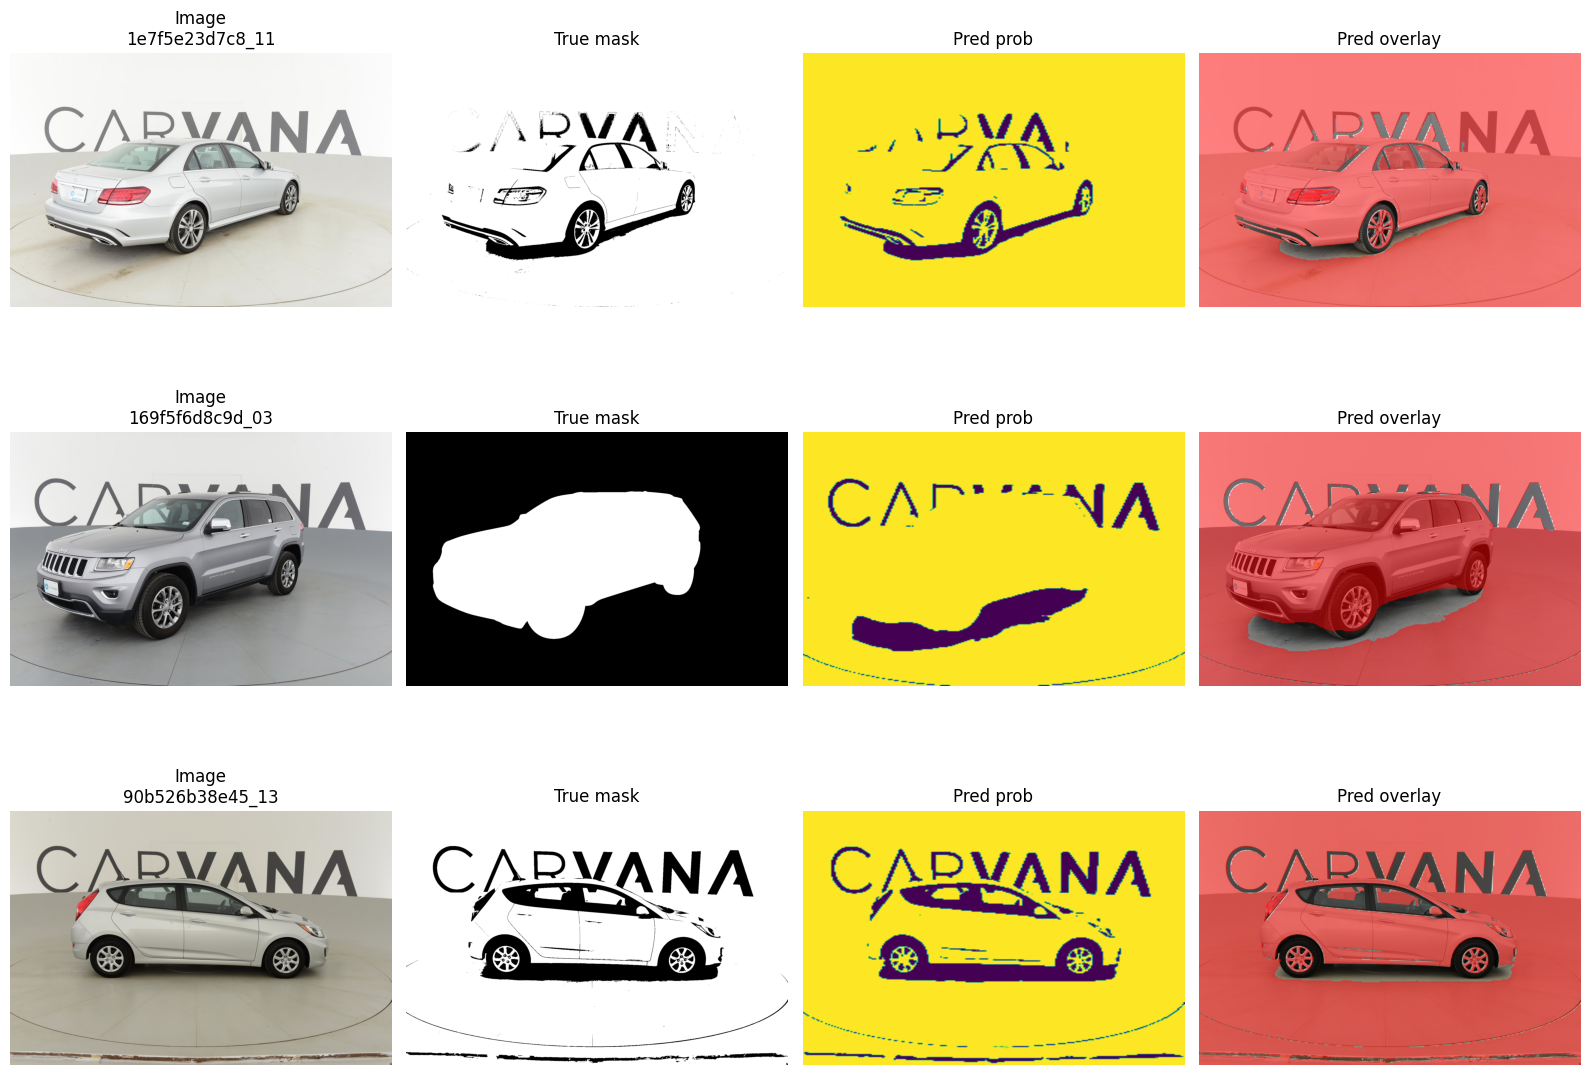

In [60]:
@torch.inference_mode()
def visualize_model_predictions(model: nn.Module, frame: pd.DataFrame, n: int = 4, seed: int = 42):
    sample = frame.sample(min(n, len(frame)), random_state=seed).reset_index(drop=True)

    fig, axes = plt.subplots(len(sample), 4, figsize=(16, 4 * len(sample)))
    if len(sample) == 1:
        axes = np.expand_dims(axes, axis=0)

    model.eval()
    for i, row in sample.iterrows():
        image = load_rgb(row["image_path"])
        true_mask = (load_mask(row["mask_path"]) > 127).astype(np.uint8)

        prob_small = predict_prob_map_unet(model, image, IMG_SIZE)
        prob_full = cv2.resize(prob_small, (true_mask.shape[1], true_mask.shape[0]), interpolation=cv2.INTER_LINEAR)
        pred_mask = (prob_full > THRESHOLD).astype(np.uint8)

        overlay = image.copy()
        overlay[pred_mask == 1] = (0.5 * overlay[pred_mask == 1] + 0.5 * np.array([255, 0, 0])).astype(np.uint8)

        axes[i, 0].imshow(image)
        axes[i, 0].set_title(f"Image\n{row['id']}")
        axes[i, 1].imshow(true_mask, cmap="gray")
        axes[i, 1].set_title("True mask")
        axes[i, 2].imshow(prob_full, cmap="viridis")
        axes[i, 2].set_title("Pred prob")
        axes[i, 3].imshow(overlay)
        axes[i, 3].set_title("Pred overlay")

        for j in range(4):
            axes[i, j].axis("off")

    plt.tight_layout()
    plt.show()

print("BCE model")
visualize_model_predictions(best_bce_model, val_df, n=3, seed=SEED)

print("Dice model")
visualize_model_predictions(best_dice_model, val_df, n=3, seed=SEED + 1)

# Собственная реализация U-Net по мотивам статьи `U-Net: Convolutional Networks for Biomedical Image Segmentation`

In [61]:
class DoubleConv(nn.Module):
    def __init__(self, in_channels: int, out_channels: int):
        super().__init__()
        self.block = nn.Sequential(
            nn.Conv2d(in_channels, out_channels, kernel_size=3, padding=1, bias=False),
            nn.BatchNorm2d(out_channels),
            nn.ReLU(inplace=True),
            nn.Conv2d(out_channels, out_channels, kernel_size=3, padding=1, bias=False),
            nn.BatchNorm2d(out_channels),
            nn.ReLU(inplace=True),
        )

    def forward(self, x):
        return self.block(x)

In [62]:
class DownBlock(nn.Module):
    def __init__(self, in_channels: int, out_channels: int):
        super().__init__()
        self.pool = nn.MaxPool2d(2)
        self.conv = DoubleConv(in_channels, out_channels)

    def forward(self, x):
        return self.conv(self.pool(x))

In [63]:
class UpBlock(nn.Module):
    def __init__(self, in_channels: int, skip_channels: int, out_channels: int):
        super().__init__()
        self.up = nn.Upsample(scale_factor=2, mode="bilinear", align_corners=False)
        self.conv = DoubleConv(in_channels + skip_channels, out_channels)

    def forward(self, x, skip):
        x = self.up(x)
        if x.shape[-2:] != skip.shape[-2:]:
            x = F.interpolate(x, size=skip.shape[-2:], mode="bilinear", align_corners=False)
        x = torch.cat([skip, x], dim=1)
        return self.conv(x)

In [64]:
class CustomUNet(nn.Module):
    def __init__(self, in_channels: int = 3, out_channels: int = 1, base_channels: int = 32):
        super().__init__()
        self.in_conv = DoubleConv(in_channels, base_channels)
        self.down1 = DownBlock(base_channels, base_channels * 2)
        self.down2 = DownBlock(base_channels * 2, base_channels * 4)
        self.down3 = DownBlock(base_channels * 4, base_channels * 8)
        self.down4 = DownBlock(base_channels * 8, base_channels * 16)
        self.bottleneck = DoubleConv(base_channels * 16, base_channels * 16)

        self.up1 = UpBlock(base_channels * 16, base_channels * 8, base_channels * 8)
        self.up2 = UpBlock(base_channels * 8, base_channels * 4, base_channels * 4)
        self.up3 = UpBlock(base_channels * 4, base_channels * 2, base_channels * 2)
        self.up4 = UpBlock(base_channels * 2, base_channels, base_channels)

        self.out_conv = nn.Conv2d(base_channels, out_channels, kernel_size=1)

    def forward(self, x):
        x1 = self.in_conv(x)
        x2 = self.down1(x1)
        x3 = self.down2(x2)
        x4 = self.down3(x3)
        x5 = self.down4(x4)
        xb = self.bottleneck(x5)

        x = self.up1(xb, x4)
        x = self.up2(x, x3)
        x = self.up3(x, x2)
        x = self.up4(x, x1)
        return self.out_conv(x)

In [65]:
custom_unet = CustomUNet(base_channels=CUSTOM_BASE_CHANNELS).to(device)
print("Custom U-Net params:", sum(p.numel() for p in custom_unet.parameters()) / 1e6, "M")

Custom U-Net params: 12.570241 M


In [66]:
custom_summary_df = None
custom_best_path = None

if RUN_CUSTOM_UNET:
    custom_model = CustomUNet(base_channels=CUSTOM_BASE_CHANNELS).to(device)
    custom_history, custom_best_path = train_model(
        model=custom_model,
        train_loader=train_loader,
        val_loader=val_loader,
        loss_fn=dice_loss,
        epochs=CUSTOM_UNET_EPOCHS,
        lr=LR,
        experiment_name="custom_unet_dice",
    )

    best_custom_model = CustomUNet(base_channels=CUSTOM_BASE_CHANNELS).to(device)
    best_custom_model.load_state_dict(torch.load(custom_best_path, map_location=device))
    custom_eval_df = evaluate_unet_on_dataframe(best_custom_model, val_df)

    custom_summary_df = pd.DataFrame(
        [
            {
                "model": "custom_unet_dice",
                "val_iou_mean": custom_eval_df["iou"].mean(),
                "val_dice_mean": custom_eval_df["dice"].mean(),
            }
        ]
    )
    display(custom_summary_df)
else:
    print("RUN_CUSTOM_UNET=False — код реализации готов, но обучение пропущено.")

RUN_CUSTOM_UNET=False — код реализации готов, но обучение пропущено.
